<a href="https://colab.research.google.com/github/parimal173/DIY_MRI_DLapproches/blob/main/Day_3_Notebook_1_1_SRR_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Super-Resolution Reconstruction Basics


    MRI spatial resolution
            ↓
    HR and LR images
            ↓
    Create LR by degradation
            ↓
    Upsampling / interpolation
            ↓
    Why interpolation ≠ SR
            ↓
    Patch extraction
            ↓
    Data augmentation
            ↓
    CNN for SR
            ↓
    Loss function
            ↓
    Optimization
            ↓
    Supervised SR training
            ↓
    Evaluation
            ↓
    Limitations of supervised SR
            ↓
    Motivation for ZSSR

  # Day 3 — Notebook 1.1
  # Super-Resolution Reconstruction (SRR) Basics

  ## Learning objectives

  By the end of this notebook, you will be able to:

      1. Explain MRI spatial resolution.
      2. Distinguish high-resolution (HR) and low-resolution (LR) images.
      3. Understand image degradation and downsampling.
      4. Explain why interpolation is not the same as super-resolution.
      5. Extract corresponding LR/HR image patches.
      6. Apply paired data augmentation.
      7. Build a small CNN for SR.
      8. Define SR reconstruction losses.
      9. Understand backpropagation and optimization.
      10. Train a simple supervised SR model.
      11. Evaluate SR using PSNR and SSIM.
      12. Understand the limitations of supervised SR.

  
    ## What can we do when we have only one LR image and no external HR target?

## Connect to GPU for Execution

    Before running the deep learning models, connect the notebook to a GPU runtime:

    Colab → Runtime → Change runtime type → Hardware accelerator → GPU

    Then verify that the GPU is available using the following code cell:

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


# Module 0 — Setup

    We will first import the libraries needed for:

    - MRI/image handling
    - visualization
    - numerical operations
    - PyTorch
    - image metrics

    We will initially work with a 2-D slice because it makes the SR concepts easier to understand.

    We will empiraclly understand the 3D volumes as well.
    

    The same concepts can later be extended to 3-D MRI volumes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch


from torch.utils.data import Dataset, DataLoader

from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


# Clone the repository

In [ ]:
!git clone https://github.com/ajaynice1996/DIY_MRI_Workshop_II_Recon

Cloning into 'DIY_MRI_Workshop_II_Recon'...
remote: Enumerating objects: 281, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 281 (delta 10), reused 8 (delta 8), pack-reused 265 (from 1)
Receiving objects: 100% (281/281), 170.63 MiB | 17.51 MiB/s, done.
Resolving deltas: 100% (100/100), done.


# Module 1 — MRI Image and Spatial Resolution

    Before discussing super-resolution, we need to understand what
    "resolution" means in MRI.

    An MRI image has:

    - matrix dimensions
    - voxel dimensions
    - field of view (FOV)

    For example:

        Matrix:       224 × 224
        Voxel size:   1 × 1 mm

    The matrix tells us how many pixels are present.

    The voxel size tells us the physical size represented by each pixel.

### Important

    Increasing the matrix size does not automatically mean that the image
    contains more true spatial information.

In [ ]:

# Workshop root directory
workshop_dir = "/content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001"

# Select image
image_path = os.path.join(
    workshop_dir,
    "3T",
    "POCEMR001_T2.nii.gz"
)

print("Loading:", image_path)

# Load NIfTI
nii = nib.load(image_path)

# Convert to NumPy array
volume = nii.get_fdata().astype(np.float32)

# Basic information
print("\nMRI information")
print("----------------")
print("Shape:", volume.shape)
print("Voxel spacing:", nii.header.get_zooms()[:3])
print("Data type:", volume.dtype)
print("Minimum intensity:", volume.min())
print("Maximum intensity:", volume.max())
print("Mean intensity:", volume.mean())
print("Standard deviation:", volume.std())

Loading: /content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001/3T/POCEMR001_T2.nii.gz

MRI information
----------------
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum intensity: 0.0
Maximum intensity: 255.0
Mean intensity: 38.78939
Standard deviation: 53.17793


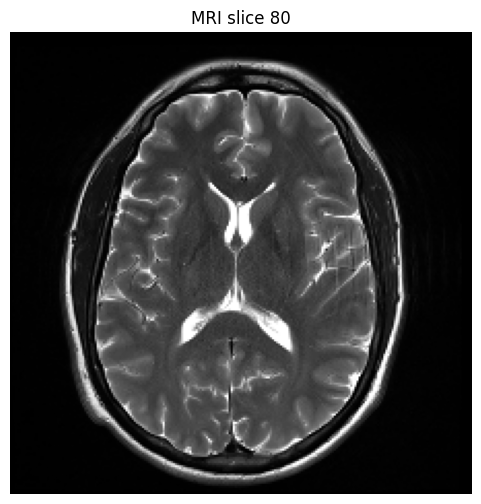

In [ ]:
# Select the middle slice
slice_idx = volume.shape[2] // 2
hr = volume[:, :, slice_idx]

plt.figure(figsize=(6, 6))
plt.imshow(hr.T, cmap="gray", origin='lower')
plt.title(f"MRI slice {slice_idx}")
plt.axis("off")
plt.show()

# High Resolution and Low Resolution

#We will use:

    HR = High Resolution
    LR = Low Resolution

#Suppose our HR image is:

    224 × 224

#If we reduce the spatial sampling by a factor of 2:

    224 × 224
          ↓
    112 × 112

#we obtain an LR representation.

#Conceptually:

              HR
               │
               │ degradation
               ↓
              LR

#The SR problem reverses this direction:

              LR
               │
               │ SR reconstruction
               ↓
              HR-like image

# What does Super-Resolution mean.

    #Super-resolution reconstructs a higher-spatial-resolution image or volume
    from one or more lower-resolution data by estimating details that are not
    explicitly resolved in the input.

# 2D example

    Suppose an MRI slice is:

    Low resolution:
    64 × 64 pixels

    and you want:

    High resolution by scale 2:
    128 × 128 pixels

    The SR model learns to produce the 128 × 128 image from the 64 × 64 image.

# Importantly, simply resizing with bicubic interpolation also gives 128 × 128 pixels, but it does not truly recover new information. SR attempts to estimate plausible high-frequency/anatomical details that are missing or poorly represented in the LR image.

#3D MRI example

    Suppose:

    Low-resolution MRI

    1 × 1 × 2 mm³ voxel spacing

    Super-resolved MRI

    1 × 1 × 1 mm³ voxel spacing

    The SR process aims to reconstruct a volume with substantially finer spatial sampling:

    Low-resolution volume
    1 × 1 × 2 mm³
          ↓
      Super-resolution
          ↓
    High-resolution volume
    1 × 1 × 1 mm³

# Understanding 3D MRI Resolution

    An MRI volume is a 3D array of **voxels**.

    Two important properties describe the volume:

    ### Matrix size
    The number of voxels in each direction.

    Example:

    **256 × 256 × 80**

    ### Voxel spacing
    The physical size represented by each voxel.

    Example:

    **1 × 1 × 1 mm³**

    These are related, but they are **not the same thing**.

    > **Matrix size tells us how many voxels we have.  
    > Voxel spacing tells us the physical resolution of those voxels.**

    In this exercise, we will simulate different MRI resolutions from the same
    original volume.

In [ ]:
from scipy.ndimage import zoom
# Convert to NumPy
volume = nii.get_fdata().astype(np.float32)

# Original voxel spacing
original_spacing = nii.header.get_zooms()[:3]

print("\nOriginal MRI Volume")
print("------------------")
print("Matrix size:", volume.shape)
print("Voxel spacing (mm):", original_spacing)
print("Data type:", volume.dtype)
print("Intensity range:", volume.min(), "to", volume.max())


Original MRI Volume
------------------
Matrix size: (224, 224, 160)
Voxel spacing (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Intensity range: 0.0 to 255.0


In [ ]:
def resample_to_spacing(volume, original_spacing, target_spacing, order=3):
    """
    Resample a 3D volume to a target voxel spacing.

    original_spacing: (sx, sy, sz) in mm
    target_spacing:   (tx, ty, tz) in mm
    """

    zoom_factors = np.array(original_spacing) / np.array(target_spacing)

    resampled = zoom(
        volume,
        zoom=zoom_factors,
        order=order
    )

    return resampled, zoom_factors

In [ ]:
target_resolutions = [
    (1, 1, 1),
    (1, 1, 2),
    (2, 2, 2),
    (1, 1, 4),
    (2, 2, 5)
]

print("Original:")
print("Spacing:", original_spacing)
print("Shape:", volume.shape)

print("\nDifferent simulated resolutions")
print("--------------------------------")

resampled_volumes = {}

for target_spacing in target_resolutions:

    resampled, factors = resample_to_spacing(
        volume,
        original_spacing,
        target_spacing,
        order=3
    )

    resampled_volumes[target_spacing] = resampled

    print(
        f"Resolution: {target_spacing} mm³ | "
        f"Zoom: {factors} | "
        f"Matrix: {resampled.shape}"
    )

Original:
Spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Shape: (224, 224, 160)

Different simulated resolutions
--------------------------------
Resolution: (1, 1, 1) mm³ | Zoom: [1. 1. 1.] | Matrix: (224, 224, 160)
Resolution: (1, 1, 2) mm³ | Zoom: [1.  1.  0.5] | Matrix: (224, 224, 80)
Resolution: (2, 2, 2) mm³ | Zoom: [0.5 0.5 0.5] | Matrix: (112, 112, 80)
Resolution: (1, 1, 4) mm³ | Zoom: [1.   1.   0.25] | Matrix: (224, 224, 40)
Resolution: (2, 2, 5) mm³ | Zoom: [0.5 0.5 0.2] | Matrix: (112, 112, 32)


## 🔍 What Happens When Resolution Decreases?

    Compare:

    **1 × 1 × 1 mm³**

    → fine spatial sampling

    **2 × 2 × 2 mm³**

    → coarser spatial sampling

    **2 × 2 × 5 mm³**

    → even coarser spatial sampling

    As voxel spacing becomes larger:

    - Fewer voxels represent the same physical region.
    - Fine anatomical structures become less well resolved.
    - Edges become less sharp.
    - Small structures may disappear or become difficult to distinguish.

    ### Key idea

    > **Larger voxel spacing = lower spatial resolution.**

    > **Smaller voxel spacing = higher spatial resolution.**

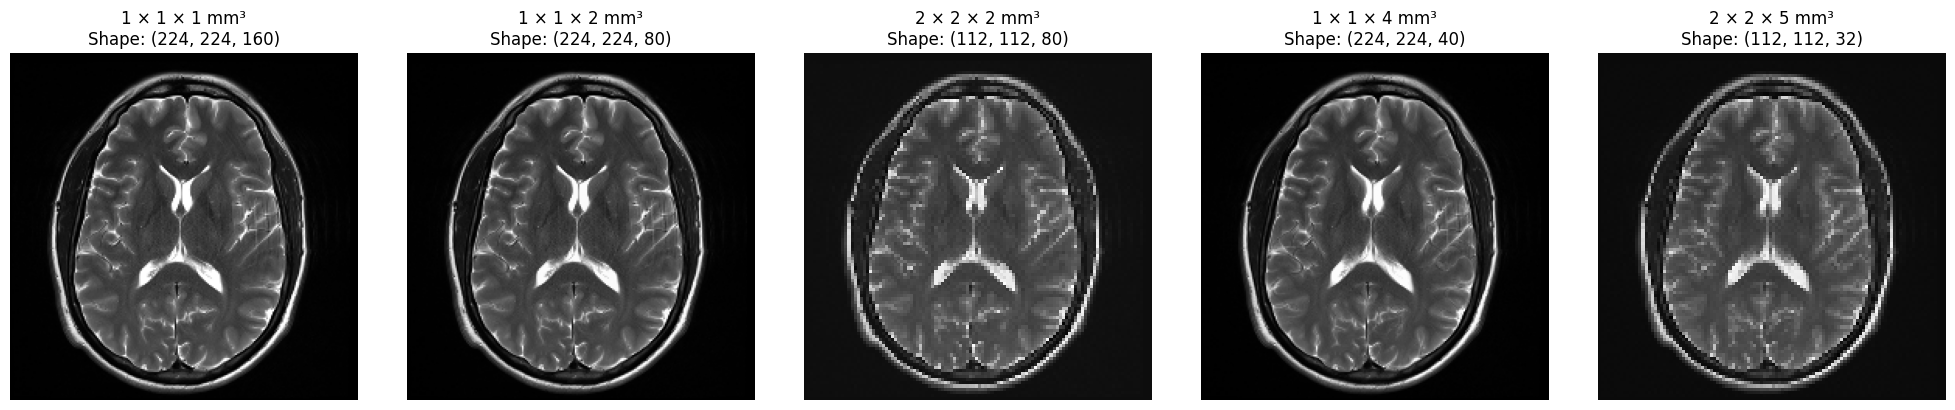

In [ ]:
# Choose the original middle slice
mid_original = volume.shape[2] // 2

fig, ax = plt.subplots(1, 5, figsize=(20, 4))

for a, target_spacing in zip(ax, target_resolutions):

    img = resampled_volumes[target_spacing]

    mid = img.shape[2] // 2

    a.imshow(
        img[:, :, mid].T,
        cmap="gray",
        origin="lower"
    )

    a.set_title(
        f"{target_spacing[0]} × "
        f"{target_spacing[1]} × "
        f"{target_spacing[2]} mm³\n"
        f"Shape: {img.shape}"
    )

    a.axis("off")

plt.tight_layout()
plt.show()

## What Do You Notice?

    All images represent the **same anatomical region**, but the spatial
    resolution is different.

    As we move from:

    **1 × 1 × 1 mm³ → 1 × 1 × 2 mm³ → 2 × 2 × 2 mm³ → 2 × 2 × 5 mm³**

    the spatial sampling becomes coarser.

    The image may appear:

    - Less sharp
    - More blurred
    - Less detailed

# Let's Understand Some Basic Experiments on 2D image

# Module 2 — Creating a Low-Resolution Image.

# Why - The Zero-shot methods based on the concept of downsampling and create multiple low-resolution variants of input image and reconstruct high-resolution variant using multiple low-resolution variants.

    A simplified degradation model is:

        LR = D(HR)

    where D is the degradation operator.

    For this notebook, D will include downsampling.

    Real MRI degradation can be more complicated and may involve:

        - acquisition resolution
        - blur
        - noise
        - reconstruction effects
        - scanner-specific characteristics
        - anisotropic sampling

    We begin with simple controlled degradation so that the SR problem
    is easy to understand.

# Normalize MRI slice

In [ ]:
import numpy as np

def normalize_image(image):
    image = image.astype(np.float32)

    min_val = image.min()
    max_val = image.max()

    if max_val == min_val:
        return np.zeros_like(image)

    image_norm = (image - min_val) / (max_val - min_val)

    return image_norm

In [ ]:
# Original MRI slice
hr_original = hr.astype(np.float32)

# Normalize HR
hr = normalize_image(hr_original)

print("Original HR:")
print("Min:", hr_original.min())
print("Max:", hr_original.max())

print("\nNormalized HR:")
print("Min:", hr.min())
print("Max:", hr.max())

Original HR:
Min: 0.0
Max: 255.0

Normalized HR:
Min: 0.0
Max: 1.0


In [ ]:
scale = 2

lr = resize(
    hr,
    (
        hr.shape[0] // scale,
        hr.shape[1] // scale
    ),
    order=3,
    preserve_range=True,
    anti_aliasing=True
).astype(np.float32)

print("HR shape:", hr.shape)
print("LR shape:", lr.shape)

HR shape: (224, 224)
LR shape: (112, 112)


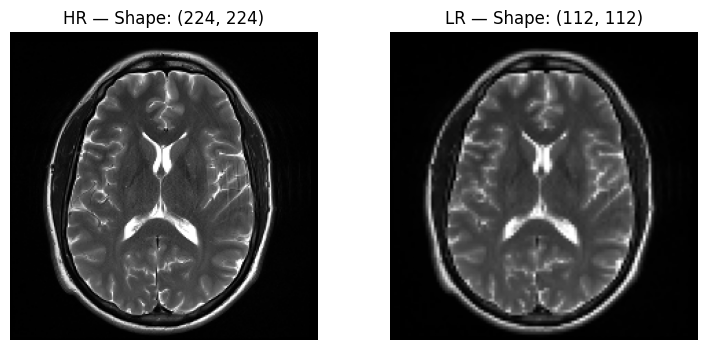

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

ax[0].imshow(
    hr.T,
    cmap="gray",
    origin="lower"
)
ax[0].set_title(f"HR — Shape: {hr.shape}")

ax[1].imshow(
    lr.T,
    cmap="gray",
    origin="lower"
)
ax[1].set_title(f"LR — Shape: {lr.shape}")

for a in ax:
    a.axis("off")

plt.show()

# Module 3 — Upsampling

#Our LR image is:

    112 × 112

#We can resize it back to:

    224 × 224

#Using interpolation.

    We will compare:

    1. Nearest-neighbor
    2. Bilinear
    3. Bicubic

    These operations increase the number of pixels.

    But:

    > Upsampling does not automatically recover information that was lost
    > during degradation.

In [ ]:
nearest = resize(
    lr,
    hr.shape,
    order=0,
    preserve_range=True,
    anti_aliasing=False
)

bilinear = resize(
    lr,
    hr.shape,
    order=1,
    preserve_range=True,
    anti_aliasing=False
)

bicubic = resize(
    lr,
    hr.shape,
    order=3,
    preserve_range=True,
    anti_aliasing=False
)

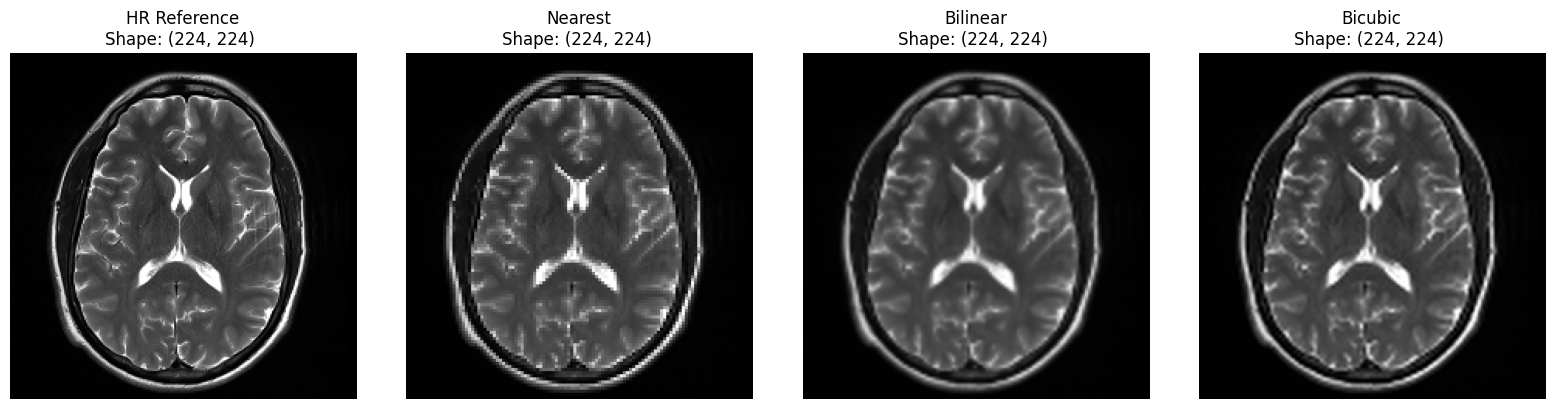

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

images = [
    hr,
    nearest,
    bilinear,
    bicubic
]

titles = [
    f"HR Reference\nShape: {hr.shape} ",
    f"Nearest\nShape: {nearest.shape} ",
    f"Bilinear\nShape: {bilinear.shape} ",
    f"Bicubic\nShape: {bicubic.shape} "
]

for a, image, title in zip(ax, images, titles):

    a.imshow(
        image.T,
        cmap="gray",
        origin="lower"
    )

    a.set_title(title)
    a.axis("off")

plt.tight_layout()
plt.show()

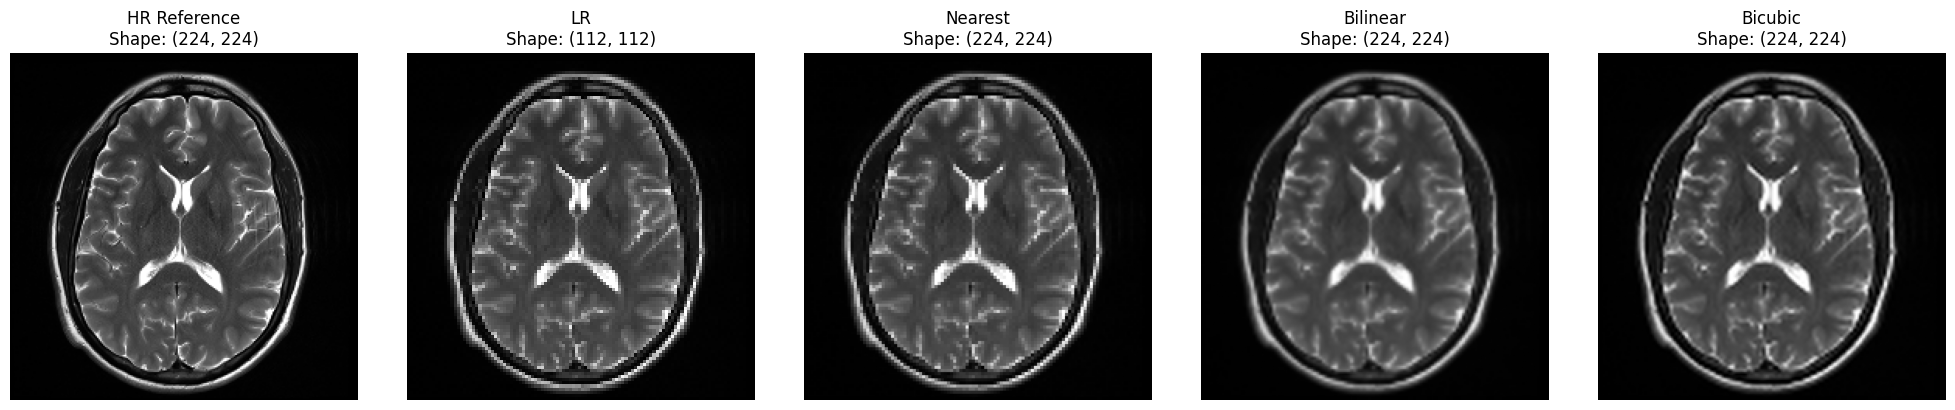

In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(20, 4))

images = [
    hr,
    lr,
    nearest,
    bilinear,
    bicubic
]

titles = [
    f"HR Reference\nShape: {hr.shape}",
    f"LR\nShape: {lr.shape}",
    f"Nearest\nShape: {nearest.shape}",
    f"Bilinear\nShape: {bilinear.shape}",
    f"Bicubic\nShape: {bicubic.shape}"
]

for a, image, title in zip(ax, images, titles):

    a.imshow(
        image.T,
        cmap="gray",
        origin="lower"
    )

    a.set_title(title)
    a.axis("off")

plt.tight_layout()
plt.show()

    ## Understand the visual differences among all the upsampling operations.

  # Module 4 — Measuring Reconstruction Quality

      ## 📊 Understanding Image Quality Metrics

  After reconstruction, we need to compare the **super-resolved image** with the **HR reference image**.

  Different metrics measure different aspects of image quality:

      ### 1. MSE — Mean Squared Error

      **MSE measures the average squared difference between the reference and reconstructed images.**

      - Measures pixel/voxel-level error.
      - **Lower MSE = better reconstruction**
      - Strongly penalizes large errors because the differences are squared.

      > 💡 Think: **"How different are the pixel values?"**

  ---

  ### 2. MAE — Mean Absolute Error

      **MAE measures the average absolute difference between the reference and reconstructed images.**

      - Measures the average magnitude of the error.
      - **Lower MAE = better reconstruction**
      - Less sensitive to large errors than MSE.

      > 💡 Think: **"On average, how much are the pixel values wrong?"**

  ---

  ### 3. PSNR — Peak Signal-to-Noise Ratio

      **PSNR measures the similarity between the reconstructed image and the reference image based on reconstruction error.**

      - Reported in **decibels (dB)**.
      - **Higher PSNR = better reconstruction**
      - Higher PSNR generally means less pixel-level error.

      > 💡 Think: **"How much reconstruction error remains?"**

  ---

  ### 4. SSIM — Structural Similarity Index

      **SSIM measures how similar the structural information is between two images.**

      It considers aspects such as:

      - Luminance
      - Contrast
      - Local structure

      For normalized images, SSIM is commonly interpreted approximately from **0 to 1**:

      - **1.0 → very similar**
      - **0.0 → very different**

      > 💡 Think: **"Does the reconstructed image preserve the same structures as the reference?"**

  ---

      ### 🔎 Why do we use multiple metrics?

      No single metric tells us everything.

      | Metric | Measures | Better |
      |---|---|---|
      | **MSE** | Squared pixel error | ↓ Lower |
      | **MAE** | Absolute pixel error | ↓ Lower |
      | **PSNR** | Reconstruction error in dB | ↑ Higher |
      | **SSIM** | Structural similarity | ↑ Higher |

  ### 🧠 Important for MRI

    A reconstruction can have a good numerical score but still fail
    to preserve an important anatomical structure.

    Therefore, **always combine quantitative metrics with visual inspection**.

      -- **Numbers tell us how similar the images are;
      -- visualization helps us determine whether important anatomical structures
      are preserved.**

In [ ]:
def mse(reference, prediction):
    return np.mean(
        (reference - prediction) ** 2
    )


def mae(reference, prediction):
    return np.mean(
        np.abs(reference - prediction)
    )


def psnr(
    reference,
    prediction,
    data_range=1.0
):

    error = mse(
        reference,
        prediction
    )

    if error == 0:
        return float("inf")

    return 10 * np.log10(
        (data_range ** 2) / error
    )

    ## See the Quantitative measures

In [ ]:
for name, prediction in [
    ("Nearest", nearest),
    ("Bilinear", bilinear),
    ("Bicubic", bicubic)
]:

    print(
        f"{name:8s} | "
        f"MSE: {mse(hr, prediction):.6f} | "
        f"MAE: {mae(hr, prediction):.6f} | "
        f"PSNR: {psnr(hr, prediction):.2f} dB | "
        f"SSIM: {ssim(hr, prediction, data_range=1.0):.4f}"
    )

Nearest  | MSE: 0.003890 | MAE: 0.026579 | PSNR: 24.10 dB | SSIM: 0.8944
Bilinear | MSE: 0.003507 | MAE: 0.026787 | PSNR: 24.55 dB | SSIM: 0.8886
Bicubic  | MSE: 0.002630 | MAE: 0.023606 | PSNR: 25.80 dB | SSIM: 0.9104


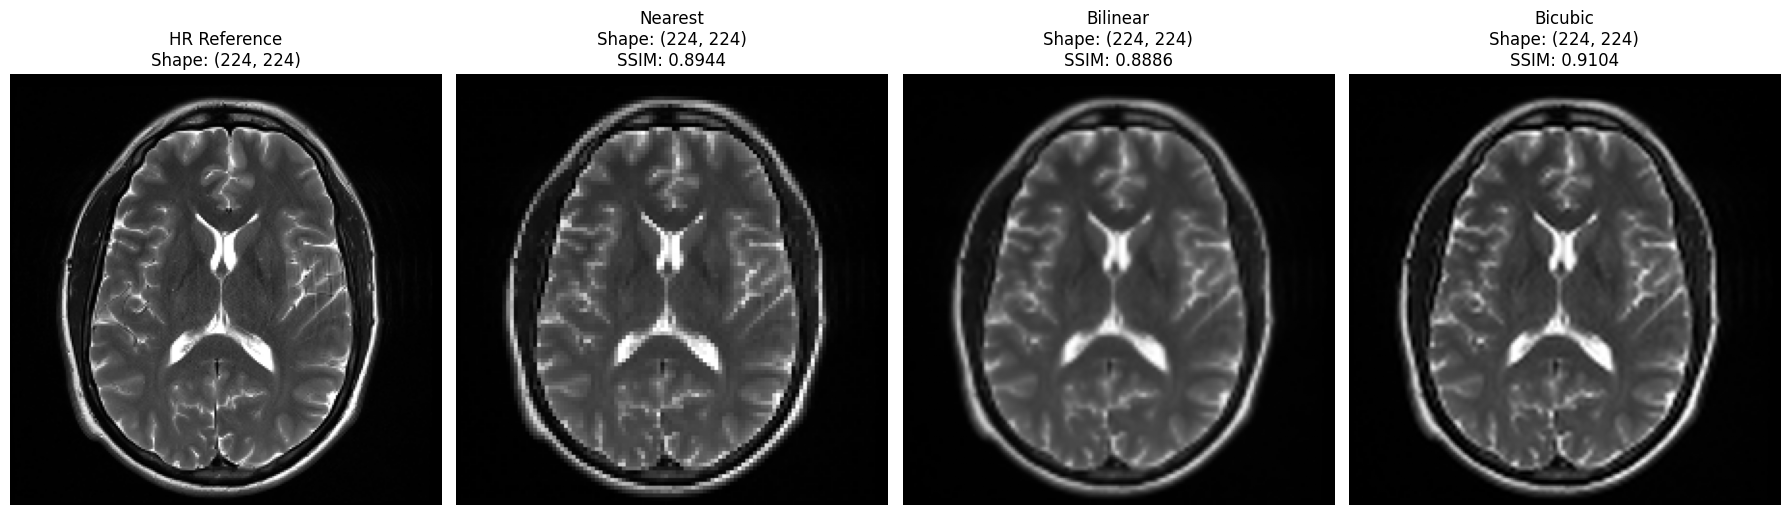

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(18, 5))

images = [
    hr,
    nearest,
    bilinear,
    bicubic
]

titles = [
    f"HR Reference\nShape: {hr.shape}",
    f"Nearest\nShape: {nearest.shape}\n"
    f"SSIM: {ssim(hr, nearest, data_range=1.0):.4f}",
    f"Bilinear\nShape: {bilinear.shape}\n"
    f"SSIM: {ssim(hr, bilinear, data_range=1.0):.4f}",
    f"Bicubic\nShape: {bicubic.shape}\n"
    f"SSIM: {ssim(hr, bicubic, data_range=1.0):.4f}"
]

for a, image, title in zip(ax, images, titles):

    a.imshow(
        image.T,
        cmap="gray",
        origin="lower"
    )

    a.set_title(title)
    a.axis("off")

plt.tight_layout()
plt.show()

    ## Observe the min-max value for the numbers

In [ ]:
print("Min/Max of each image:")
print("-----------------------")

for name, image in [
    ("LR", lr),
    ("Nearest", nearest),
    ("Bilinear", bilinear),
    ("Bicubic", bicubic),
    ("HR reference", hr)
]:
    print(f"{name:12s} | Min: {image.min():.4f}, Max: {image.max():.4f}")

Min/Max of each image:
-----------------------
LR           | Min: 0.0000, Max: 1.0000
Nearest      | Min: 0.0000, Max: 1.0000
Bilinear     | Min: 0.0000, Max: 0.9999
Bicubic      | Min: 0.0000, Max: 1.0000
HR reference | Min: 0.0000, Max: 1.0000


## What Did We Learn? — From Interpolation

    We started with a **high-resolution (HR) reference** and created
    a **low-resolution (LR) image**.

    When we upsample the LR image using:

    - Nearest-neighbor interpolation  
    - Bilinear interpolation
    - Bicubic interpolation

    we can increase the **image size**, but we cannot truly recover
    the information that was lost when the image was converted from HR → LR.

### HR → LR → Upsampling

    If interpolation cannot recover the information
    lost during HR → LR conversion:

### **How can we recover the missing details?**

This motivates **learning-based super-resolution**.

Instead of simply interpolating the LR image, we can train a neural network to learn:

**LR image → HR image**

    The network can learn patterns such as:

    - Edges
    - Textures
    - Anatomical structures
    - High-frequency information
    - Relationships between low- and high-resolution images

---

## Motivation for Learning-Based Super-Resolution

### Learning-based SR

**LR → Neural Network → Estimated HR**

### Take-Home Message

**Upsampling ≠ Super-resolution**

- **Upsampling** increases image size.
- **Interpolation** estimates missing pixel/voxel values using mathematical rules.
- **Super-resolution** attempts to reconstruct a higher-resolution representation by exploiting learned or image-specific information.
- **Quantitative metrics + visual/anatomical evaluation** are both needed to assess the reconstruction.

# Module 5 — From Interpolation to Learned SR

Interpolation uses a fixed mathematical rule.

A neural network instead tries to learn a mapping:

    SR = fθ(LR)

where:

- LR = low-resolution input
- SR = predicted high-resolution image
- fθ = neural network
- θ = learnable parameters

The network is trained using an HR target:

                HR target
                    ↑
                    │
    LR → CNN → SR → Loss
                    │
                    ↓
               optimization

The objective is:

    θ* = argminθ L(fθ(LR), HR)

#  Some Intermediate training strategies

##  Patch Extraction

Large images are often divided into smaller patches.

Why?

- Lower memory requirement
- More training samples
- Easier augmentation
- Learning local image structures

For a scale factor of 2:

    HR patch = 32 × 32
    LR patch = 16 × 16

The LR and HR patches must correspond to the same anatomical region.

This is called an aligned LR-HR pair.

In [ ]:
def extract_aligned_patches(
    lr,
    hr,
    patch_hr=32,
    scale=2,
    stride=16
):

    patch_lr = patch_hr // scale

    lr_patches = []
    hr_patches = []

    for r_hr in range(
        0,
        hr.shape[0] - patch_hr + 1,
        stride
    ):

        for c_hr in range(
            0,
            hr.shape[1] - patch_hr + 1,
            stride
        ):

            r_lr = r_hr // scale
            c_lr = c_hr // scale

            hr_patch = hr[
                r_hr:r_hr + patch_hr,
                c_hr:c_hr + patch_hr
            ]

            lr_patch = lr[
                r_lr:r_lr + patch_lr,
                c_lr:c_lr + patch_lr
            ]

            lr_patches.append(lr_patch)
            hr_patches.append(hr_patch)

    return (
        np.stack(lr_patches),
        np.stack(hr_patches)
    )

In [ ]:
lr_patches, hr_patches = extract_aligned_patches(
    lr,
    hr,
    patch_hr=32,
    scale=2,
    stride=16
)

print("Number of patches:", len(lr_patches))
print("LR patches:", lr_patches.shape)
print("HR patches:", hr_patches.shape)

Number of patches: 169
LR patches: (169, 16, 16)
HR patches: (169, 32, 32)


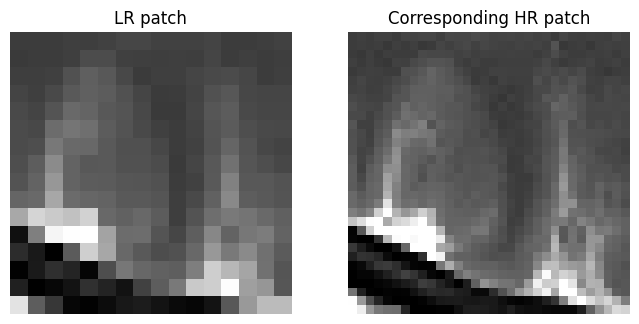

In [ ]:
patch_id = 120

fig, ax = plt.subplots(
    1, 2,
    figsize=(8, 4)
)

ax[0].imshow(
    lr_patches[patch_id],
    cmap="gray"

)

ax[0].set_title("LR patch")

ax[1].imshow(
    hr_patches[patch_id],
    cmap="gray"

)

ax[1].set_title("Corresponding HR patch")

for a in ax:
    a.axis("off")

plt.show()

## Student Exercise —

    1. Change the Patch Size

      Try:

          patch_hr = 48

      instead of:

          patch_hr = 32

      Then answer:

      1. How many patches are generated?
      2. What is the corresponding LR patch size?
      3. What happens to the number of training examples?
      4. What happens if the stride is reduced?

      Try:

          stride = 8


    2. Experiment different patch_id.

## Data Augmentation

  We can create additional training examples using transformations.

  Examples:

  - horizontal flip
  - vertical flip
  - rotation

  ### Critical rule

  The same spatial transformation must be applied to both LR and HR.

  Correct:

      LR → rotate
      HR → rotate

  Incorrect:

      LR → rotate
      HR → unchanged

# Module 6 — A Small CNN for SR

    We will begin with a deliberately small network.

    The idea is:

        LR
        ↓
        Conv
        ↓
        ReLU
        ↓
        Conv
        ↓
        ReLU
        ↓
        Conv
        ↓
        SR

    We will first use bicubic interpolation to change the spatial size.

    Therefore:

        LR
        ↓
        Bicubic ×2
        ↓
        CNN
        ↓
        SR

    This keeps the first CNN exercise simple.

    Later, learned upsampling methods such as PixelShuffle can be introduced.

In [ ]:
class SmallSRNet(nn.Module):

    def __init__(
        self,
        channels=32
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            channels,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            channels,
            1,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU(
            inplace=True
        )

    def forward(self, x):

        x = F.interpolate(
            x,
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        x = self.relu(
            self.conv1(x)
        )

        x = self.relu(
            self.conv2(x)
        )

        x = self.conv3(x)

        return x

# Student Exercise — Build Your Own SR CNN

Complete the missing parts.

```python
class MySRNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = ______________________

        self.conv2 = ______________________

        self.conv3 = ______________________

    def forward(self, x):

        x = ______________________

        x = ______________________

        x = ______________________

        x = ______________________

        x = ______________________

        return x


---

# Module 7 — PyTorch dataset


```markdown
# Module 12 — Preparing the Training Dataset

Our supervised SR dataset consists of:

    LR patch ↔ HR patch

The network receives the LR patch.

The HR patch is the target.

In [ ]:
class SRPatchDataset(Dataset):

    def __init__(
        self,
        lr_patches,
        hr_patches
    ):

        self.lr = lr_patches.astype(
            np.float32
        )

        self.hr = hr_patches.astype(
            np.float32
        )

    def __len__(self):
        return len(self.lr)

    def __getitem__(self, idx):

        lr = torch.from_numpy(
            self.lr[idx]
        ).unsqueeze(0)

        hr = torch.from_numpy(
            self.hr[idx]
        ).unsqueeze(0)

        return lr, hr

In [ ]:
dataset = SRPatchDataset(
    lr_patches,
    hr_patches
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

lr_batch, hr_batch = next(
    iter(loader)
)

print("LR batch:", lr_batch.shape)
print("HR batch:", hr_batch.shape)

LR batch: torch.Size([8, 1, 16, 16])
HR batch: torch.Size([8, 1, 32, 32])


# Module 13 — Reconstruction Loss

The network produces:

    SR prediction

We compare it with:

    HR target

A simple loss is MSE:

        1
L = ------- Σ (SR - HR)²
        N

Another common loss is MAE/L1:

        1
L = ------- Σ |SR - HR|
        N

In [ ]:
def mse_loss(
    prediction,
    target
):

    return torch.mean(
        (prediction - target) ** 2
    )


def mae_loss(
    prediction,
    target
):

    return torch.mean(
        torch.abs(
            prediction - target
        )
    )


---

# Module 14 — Optimization


```markdown
# Module 14 — Optimization

Training follows this cycle:

    LR
     ↓
    CNN
     ↓
    SR prediction
     ↓
    Loss(SR, HR)
     ↓
    Backpropagation
     ↓
    Optimizer
     ↓
    Update network parameters
     ↓
    Repeat

The optimizer changes the CNN parameters so that
the reconstruction loss decreases.

In [ ]:
model = SmallSRNet().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(model)
print(optimizer)

SmallSRNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU(inplace=True)
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Module 8 — Training loop

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0

    for lr_batch, hr_batch in loader:

        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        optimizer.zero_grad()

        prediction = model(
            lr_batch
        )

        loss = criterion(
            prediction,
            hr_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return (
        running_loss / len(loader)
    )

In [ ]:
model = SmallSRNet().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

loss_history = []

num_epochs = 100

for epoch in range(num_epochs):

    loss = train_one_epoch(
        model,
        loader,
        optimizer,
        criterion,
        device
    )

    loss_history.append(loss)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss = {loss:.6f}"
    )

Epoch 01 | Loss = 0.032865
Epoch 02 | Loss = 0.009758
Epoch 03 | Loss = 0.005840
Epoch 04 | Loss = 0.004116
Epoch 05 | Loss = 0.003521
Epoch 06 | Loss = 0.003197
Epoch 07 | Loss = 0.002975
Epoch 08 | Loss = 0.003090
Epoch 09 | Loss = 0.002806
Epoch 10 | Loss = 0.002933
Epoch 11 | Loss = 0.002752
Epoch 12 | Loss = 0.002947
Epoch 13 | Loss = 0.002890
Epoch 14 | Loss = 0.002697
Epoch 15 | Loss = 0.002819
Epoch 16 | Loss = 0.002776
Epoch 17 | Loss = 0.002781
Epoch 18 | Loss = 0.002737
Epoch 19 | Loss = 0.002843
Epoch 20 | Loss = 0.002743
Epoch 21 | Loss = 0.002555
Epoch 22 | Loss = 0.002649
Epoch 23 | Loss = 0.002741
Epoch 24 | Loss = 0.002498
Epoch 25 | Loss = 0.002502
Epoch 26 | Loss = 0.002477
Epoch 27 | Loss = 0.002777
Epoch 28 | Loss = 0.002602
Epoch 29 | Loss = 0.002569
Epoch 30 | Loss = 0.002662
Epoch 31 | Loss = 0.002545
Epoch 32 | Loss = 0.002406
Epoch 33 | Loss = 0.002570
Epoch 34 | Loss = 0.002471
Epoch 35 | Loss = 0.002452
Epoch 36 | Loss = 0.002486
Epoch 37 | Loss = 0.002399
E

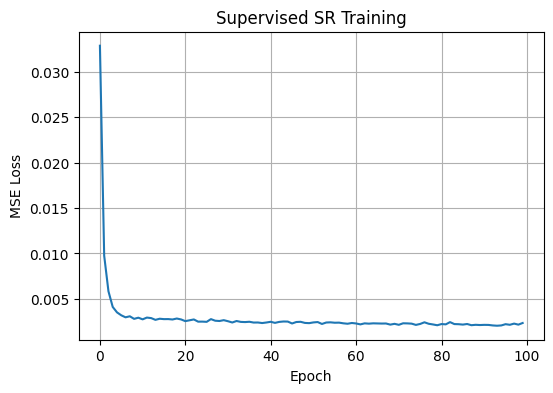

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Supervised SR Training")

plt.grid(True)

plt.show()

# Reconstruction

The network has now learned from LR-HR patch pairs.

We can provide the LR image to the trained network:

    LR
     ↓
    trained CNN
     ↓
    SR

In [ ]:


model.eval()

lr_tensor = torch.from_numpy(
    lr
).float().unsqueeze(0).unsqueeze(0)

lr_tensor = lr_tensor.to(device)

with torch.no_grad():

    sr_prediction = model(
        lr_tensor
    )

sr_prediction = (
    sr_prediction
    .squeeze()
    .cpu()
    .numpy()
)

sr_prediction = np.clip(
    sr_prediction,
    0,
    1
)

print("LR:", lr.shape)
print("SR:", sr_prediction.shape)
print("HR:", hr.shape)

LR: (112, 112)
SR: (224, 224)
HR: (224, 224)


In [ ]:
print("Min/Max of each image:")
print("-----------------------")

for name, image in [
    ("LR", lr),
    ("Bicubic", bicubic),
    ("CNN SR", sr_prediction),
    ("HR reference", hr)
]:
    print(f"{name:12s} | Min: {image.min():.4f}, Max: {image.max():.4f}")

Min/Max of each image:
-----------------------
LR           | Min: 0.0000, Max: 1.0000
Bicubic      | Min: 0.0000, Max: 1.0000
CNN SR       | Min: 0.0000, Max: 1.0000
HR reference | Min: 0.0000, Max: 1.0000


# Just a critical test on the model trained on same slice

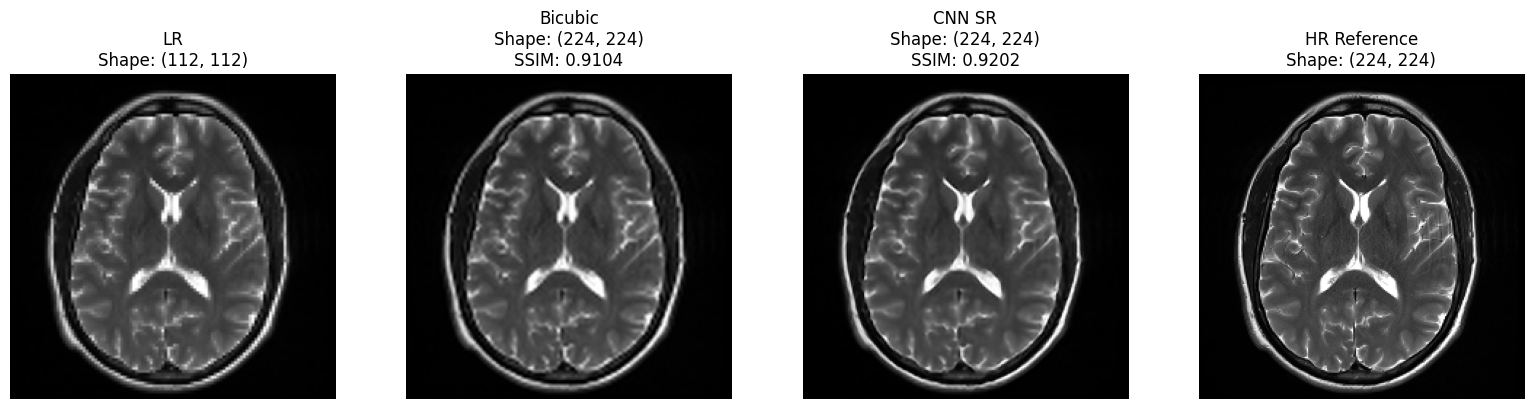

Bicubic
PSNR: 25.799744
SSIM: 0.9104110473414002

CNN SR
PSNR: 27.55402
SSIM: 0.9201885855049801


In [ ]:
fig, ax = plt.subplots(
    1, 4,
    figsize=(16, 4)
)

# Calculate SSIM
bicubic_ssim = ssim(
    hr,
    bicubic,
    data_range=1.0
)

cnn_ssim = ssim(
    hr,
    sr_prediction,
    data_range=1.0
)

ax[0].imshow(
    lr.T,
    cmap="gray",
    origin="lower"
)
ax[0].set_title(
    f"LR\nShape: {lr.shape}"
)

ax[1].imshow(
    bicubic.T,
    cmap="gray",
    origin="lower"
)
ax[1].set_title(
    f"Bicubic\n"
    f"Shape: {bicubic.shape}\n"
    f"SSIM: {bicubic_ssim:.4f}"
)

ax[2].imshow(
    sr_prediction.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
ax[2].set_title(
    f"CNN SR\n"
    f"Shape: {sr_prediction.shape}\n"
    f"SSIM: {cnn_ssim:.4f}"
)

ax[3].imshow(
    hr.T,
    cmap="gray",
    origin="lower"
)
ax[3].set_title(
    f"HR Reference\n"
    f"Shape: {hr.shape}"
)

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

print("Bicubic")
print(
    "PSNR:",
    psnr(hr, bicubic)
)
print(
    "SSIM:",
    ssim(
        hr,
        bicubic,
        data_range=1.0
    )
)

print("\nCNN SR")
print(
    "PSNR:",
    psnr(hr, sr_prediction)
)
print(
    "SSIM:",
    ssim(
        hr,
        sr_prediction,
        data_range=1.0
    )
)

# The model is trained on the single 2D slice from the volume; Lets test on another slice using the LR input

Selecting slice 85

[1] HR slice selected
Slice index: 85
Original HR input shape: (224, 224)
Original intensity range: 0.0000 to 255.0000

[2] Performing normalization...
Normalization completed
HR normalized shape: (224, 224)
Normalized intensity range: 0.0000 to 1.0000

[3] Creating low-resolution (LR) image...
LR image created
HR input shape: (224, 224)
LR input shape: (112, 112)
Downsampling scale: 2×

[4] Performing Bicubic interpolation...
Bicubic interpolation completed
LR shape: (112, 112)
Bicubic output shape: (224, 224)

[5] Performing CNN Super-Resolution...
CNN input tensor shape: torch.Size([1, 1, 112, 112])
CNN SR completed
CNN SR output shape: (224, 224)

[6] Calculating SSIM...
Bicubic SSIM: 0.9219
CNN SR SSIM:  0.9336

[7] Displaying results...


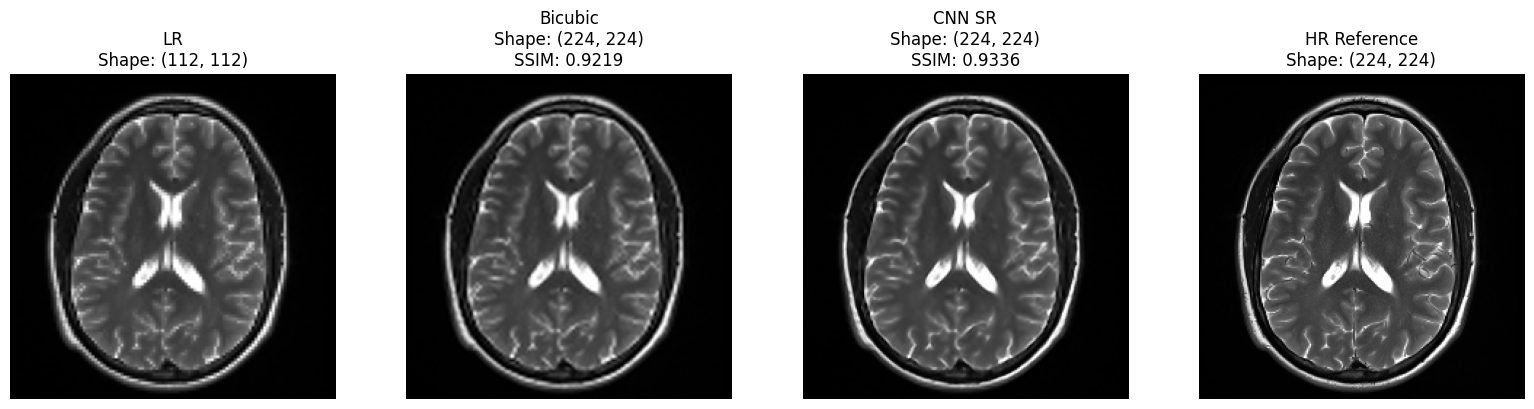


Evaluation for New Slice

Bicubic
PSNR: 26.45 dB
SSIM: 0.9219

CNN SR
PSNR: 28.07 dB
SSIM: 0.9336

Min/Max Intensity Values
LR              | Min: 0.0000, Max: 1.0000
Bicubic         | Min: 0.0000, Max: 1.0000
CNN SR          | Min: 0.0000, Max: 1.0000
HR Reference    | Min: 0.0000, Max: 1.0000


In [ ]:
# ============================================================
# New Slice → LR → Bicubic → CNN SR → HR Reference
# ============================================================

new_slice_idx = 85

print("=" * 60)
print(f"Selecting slice {new_slice_idx}")
print("=" * 60)

# ------------------------------------------------------------
# 1. Select HR slice
# ------------------------------------------------------------

hr_new_original = volume[:, :, new_slice_idx].astype(np.float32)

print("\n[1] HR slice selected")
print(f"Slice index: {new_slice_idx}")
print(f"Original HR input shape: {hr_new_original.shape}")
print(
    f"Original intensity range: "
    f"{hr_new_original.min():.4f} to {hr_new_original.max():.4f}"
)

# ------------------------------------------------------------
# 2. Normalize HR slice
# ------------------------------------------------------------

print("\n[2] Performing normalization...")

hr_new = normalize_image(hr_new_original)

print("Normalization completed")
print(f"HR normalized shape: {hr_new.shape}")
print(
    f"Normalized intensity range: "
    f"{hr_new.min():.4f} to {hr_new.max():.4f}"
)

# ------------------------------------------------------------
# 3. Create LR image
# ------------------------------------------------------------

print("\n[3] Creating low-resolution (LR) image...")

lr_new = resize(
    hr_new,
    (
        hr_new.shape[0] // scale,
        hr_new.shape[1] // scale
    ),
    order=3,
    preserve_range=True,
    anti_aliasing=True
).astype(np.float32)

print("LR image created")
print(f"HR input shape: {hr_new.shape}")
print(f"LR input shape: {lr_new.shape}")
print(f"Downsampling scale: {scale}×")

# ------------------------------------------------------------
# 4. Bicubic interpolation
# ------------------------------------------------------------

print("\n[4] Performing Bicubic interpolation...")

bicubic_new = resize(
    lr_new,
    hr_new.shape,
    order=3,
    preserve_range=True,
    anti_aliasing=False
).astype(np.float32)

print("Bicubic interpolation completed")
print(f"LR shape: {lr_new.shape}")
print(f"Bicubic output shape: {bicubic_new.shape}")

# ------------------------------------------------------------
# 5. CNN Super-Resolution
# ------------------------------------------------------------

print("\n[5] Performing CNN Super-Resolution...")

model.eval()

lr_new_tensor = torch.from_numpy(
    lr_new
).float().unsqueeze(0).unsqueeze(0)

lr_new_tensor = lr_new_tensor.to(device)

print(f"CNN input tensor shape: {lr_new_tensor.shape}")

with torch.no_grad():
    sr_prediction_new = model(
        lr_new_tensor
    )

sr_prediction_new = (
    sr_prediction_new
    .squeeze()
    .cpu()
    .numpy()
)

sr_prediction_new = np.clip(
    sr_prediction_new,
    0,
    1
)

print("CNN SR completed")
print(f"CNN SR output shape: {sr_prediction_new.shape}")

# ------------------------------------------------------------
# 6. Calculate SSIM
# ------------------------------------------------------------

print("\n[6] Calculating SSIM...")

bicubic_ssim_new = ssim(
    hr_new,
    bicubic_new,
    data_range=1.0
)

cnn_ssim_new = ssim(
    hr_new,
    sr_prediction_new,
    data_range=1.0
)

print(f"Bicubic SSIM: {bicubic_ssim_new:.4f}")
print(f"CNN SR SSIM:  {cnn_ssim_new:.4f}")

# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

print("\n[7] Displaying results...")

fig, ax = plt.subplots(
    1, 4,
    figsize=(16, 4)
)

ax[0].imshow(
    lr_new.T,
    cmap="gray",
    origin="lower"
)
ax[0].set_title(
    f"LR\n"
    f"Shape: {lr_new.shape}"
)

ax[1].imshow(
    bicubic_new.T,
    cmap="gray",
    origin="lower"
)
ax[1].set_title(
    f"Bicubic\n"
    f"Shape: {bicubic_new.shape}\n"
    f"SSIM: {bicubic_ssim_new:.4f}"
)

ax[2].imshow(
    sr_prediction_new.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
ax[2].set_title(
    f"CNN SR\n"
    f"Shape: {sr_prediction_new.shape}\n"
    f"SSIM: {cnn_ssim_new:.4f}"
)

ax[3].imshow(
    hr_new.T,
    cmap="gray",
    origin="lower"
)
ax[3].set_title(
    f"HR Reference\n"
    f"Shape: {hr_new.shape}"
)

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Calculate PSNR and print evaluation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Evaluation for New Slice")
print("=" * 60)

bicubic_psnr_new = psnr(
    hr_new,
    bicubic_new
)

cnn_psnr_new = psnr(
    hr_new,
    sr_prediction_new
)

print("\nBicubic")
print(f"PSNR: {bicubic_psnr_new:.2f} dB")
print(f"SSIM: {bicubic_ssim_new:.4f}")

print("\nCNN SR")
print(f"PSNR: {cnn_psnr_new:.2f} dB")
print(f"SSIM: {cnn_ssim_new:.4f}")

# ------------------------------------------------------------
# 9. Print min/max values
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Min/Max Intensity Values")
print("=" * 60)

for name, image in [
    ("LR", lr_new),
    ("Bicubic", bicubic_new),
    ("CNN SR", sr_prediction_new),
    ("HR Reference", hr_new)
]:
    print(
        f"{name:15s} | "
        f"Min: {image.min():.4f}, "
        f"Max: {image.max():.4f}"
    )

# Check above for Multiple test Slices and Better Training of model for more epochs;

# Module 9 — Understanding Supervised SR

  We trained the network using:

      LR₁ ↔ HR₁
      LR₂ ↔ HR₂
      LR₃ ↔ HR₃
      ...
      LRₙ ↔ HRₙ

  The network learned:

      fθ(LR) → HR-like reconstruction

  The HR image was explicitly available during training.

  This is called:

      # Supervised Super-Resolution

# Module 10 -- Understanding Low-field (64mT) and High-field (3T) images

## Excercise

    Note:Super-Resolution Reconstruction (SRR) primarily means improving
    spatial resolution—not simply improving overall image quality.

In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Workshop root directory
# ============================================================

workshop_dir = "/drive/MyDrive/1DIY_MRI_Recon/data/"


# ============================================================
# 1. Load 3T MRI
# ============================================================

path_3T = os.path.join(
    workshop_dir,
    "3T",
    "POCEMR001_T2.nii.gz"
)

print("Loading 3T:", path_3T)

nii_3T = nib.load(path_3T)
mri_3T = nii_3T.get_fdata().astype(np.float32)


# ============================================================
# 2. Load 64 mT MRI
# ============================================================

path_64mT = os.path.join(
    workshop_dir,
    "64mT",
    "POCEMR001_T2.nii.gz"
)

print("Loading 64 mT:", path_64mT)

nii_64mT = nib.load(path_64mT)
mri_64mT = nii_64mT.get_fdata().astype(np.float32)


# ============================================================
# 3. Print information
# ============================================================

print("\n" + "=" * 60)
print("3T MRI")
print("=" * 60)

print("Shape:", mri_3T.shape)
print("Voxel spacing:", nii_3T.header.get_zooms()[:3])
print("Data type:", mri_3T.dtype)
print("Minimum intensity:", mri_3T.min())
print("Maximum intensity:", mri_3T.max())
print("Mean intensity:", mri_3T.mean())
print("Standard deviation:", mri_3T.std())


print("\n" + "=" * 60)
print("64 mT Low-Field MRI")
print("=" * 60)

print("Shape:", mri_64mT.shape)
print("Voxel spacing:", nii_64mT.header.get_zooms()[:3])
print("Data type:", mri_64mT.dtype)
print("Minimum intensity:", mri_64mT.min())
print("Maximum intensity:", mri_64mT.max())
print("Mean intensity:", mri_64mT.mean())
print("Standard deviation:", mri_64mT.std())

Loading 3T: /drive/MyDrive/1DIY_MRI_Recon/data/3T/POCEMR001_T2.nii.gz
Loading 64 mT: /drive/MyDrive/1DIY_MRI_Recon/data/64mT/POCEMR001_T2.nii.gz

3T MRI
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum intensity: 0.0
Maximum intensity: 255.0
Mean intensity: 38.78939
Standard deviation: 53.17793

64 mT Low-Field MRI
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum intensity: 0.0
Maximum intensity: 255.0
Mean intensity: 44.35543
Standard deviation: 56.47321


In [ ]:
def normalize_volume(volume):
    volume_min = volume.min()
    volume_max = volume.max()

    return (
        (volume - volume_min) /
        (volume_max - volume_min)
    ).astype(np.float32)


mri_3T_norm = normalize_volume(mri_3T)
mri_64mT_norm = normalize_volume(mri_64mT)

print("3T normalized range:",
      mri_3T_norm.min(), "to", mri_3T_norm.max())

print("64 mT normalized range:",
      mri_64mT_norm.min(), "to", mri_64mT_norm.max())

3T normalized range: 0.0 to 1.0
64 mT normalized range: 0.0 to 1.0


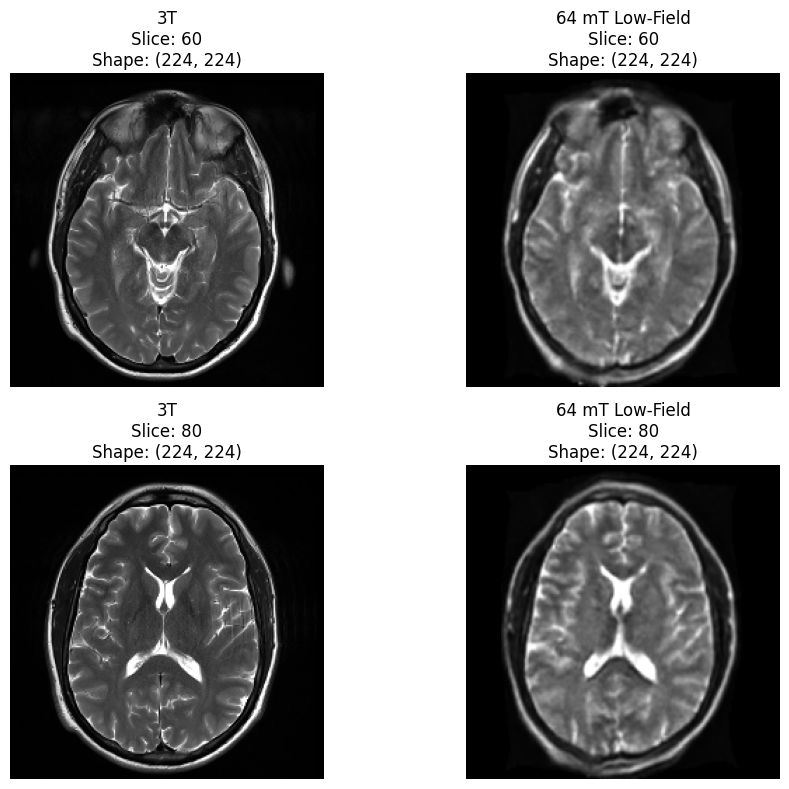

In [ ]:
# Choose several slice indices
slice_indices = [60, 80]

fig, ax = plt.subplots(
    len(slice_indices),
    2,
    figsize=(10, 4 * len(slice_indices))
)

for row, slice_idx in enumerate(slice_indices):

    # 3T
    ax[row, 0].imshow(
        mri_3T_norm[:, :, slice_idx].T,
        cmap="gray",
        origin="lower"
    )

    ax[row, 0].set_title(
        f"3T\nSlice: {slice_idx}\n"
        f"Shape: {mri_3T.shape[:2]}"
    )

    # 64 mT
    ax[row, 1].imshow(
        mri_64mT_norm[:, :, slice_idx].T,
        cmap="gray",
        origin="lower"
    )

    ax[row, 1].set_title(
        f"64 mT Low-Field\nSlice: {slice_idx}\n"
        f"Shape: {mri_64mT.shape[:2]}"
    )

    ax[row, 0].axis("off")
    ax[row, 1].axis("off")

plt.tight_layout()
plt.show()

# T1w

In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Workshop root directory
# ============================================================

workshop_dir = "/drive/MyDrive/1DIY_MRI_Recon/data/"


# ============================================================
# 1. Load 3T MRI
# ============================================================

path_3T = os.path.join(
    workshop_dir,
    "3T",
    "POCEMR001_T1.nii.gz"
)

print("Loading 3T:", path_3T)

nii_3T = nib.load(path_3T)
mri_3T = nii_3T.get_fdata().astype(np.float32)


# ============================================================
# 2. Load 64 mT MRI
# ============================================================

path_64mT = os.path.join(
    workshop_dir,
    "64mT",
    "POCEMR001_T1.nii.gz"
)

print("Loading 64 mT:", path_64mT)

nii_64mT = nib.load(path_64mT)
mri_64mT = nii_64mT.get_fdata().astype(np.float32)


# ============================================================
# 3. Print information
# ============================================================

print("\n" + "=" * 60)
print("3T MRI")
print("=" * 60)

print("Shape:", mri_3T.shape)
print("Voxel spacing:", nii_3T.header.get_zooms()[:3])
print("Data type:", mri_3T.dtype)
print("Minimum intensity:", mri_3T.min())
print("Maximum intensity:", mri_3T.max())
print("Mean intensity:", mri_3T.mean())
print("Standard deviation:", mri_3T.std())


print("\n" + "=" * 60)
print("64 mT Low-Field MRI")
print("=" * 60)

print("Shape:", mri_64mT.shape)
print("Voxel spacing:", nii_64mT.header.get_zooms()[:3])
print("Data type:", mri_64mT.dtype)
print("Minimum intensity:", mri_64mT.min())
print("Maximum intensity:", mri_64mT.max())
print("Mean intensity:", mri_64mT.mean())
print("Standard deviation:", mri_64mT.std())

Loading 3T: /drive/MyDrive/1DIY_MRI_Recon/data/3T/POCEMR001_T1.nii.gz
Loading 64 mT: /drive/MyDrive/1DIY_MRI_Recon/data/64mT/POCEMR001_T1.nii.gz

3T MRI
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum intensity: 0.0
Maximum intensity: 255.0
Mean intensity: 41.975918
Standard deviation: 55.04397

64 mT Low-Field MRI
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum intensity: 0.0
Maximum intensity: 255.0
Mean intensity: 55.128082
Standard deviation: 64.14627


In [ ]:
def normalize_volume(volume):
    volume_min = volume.min()
    volume_max = volume.max()

    return (
        (volume - volume_min) /
        (volume_max - volume_min)
    ).astype(np.float32)


mri_3T_norm = normalize_volume(mri_3T)
mri_64mT_norm = normalize_volume(mri_64mT)

print("3T normalized range:",
      mri_3T_norm.min(), "to", mri_3T_norm.max())

print("64 mT normalized range:",
      mri_64mT_norm.min(), "to", mri_64mT_norm.max())

3T normalized range: 0.0 to 1.0
64 mT normalized range: 0.0 to 1.0


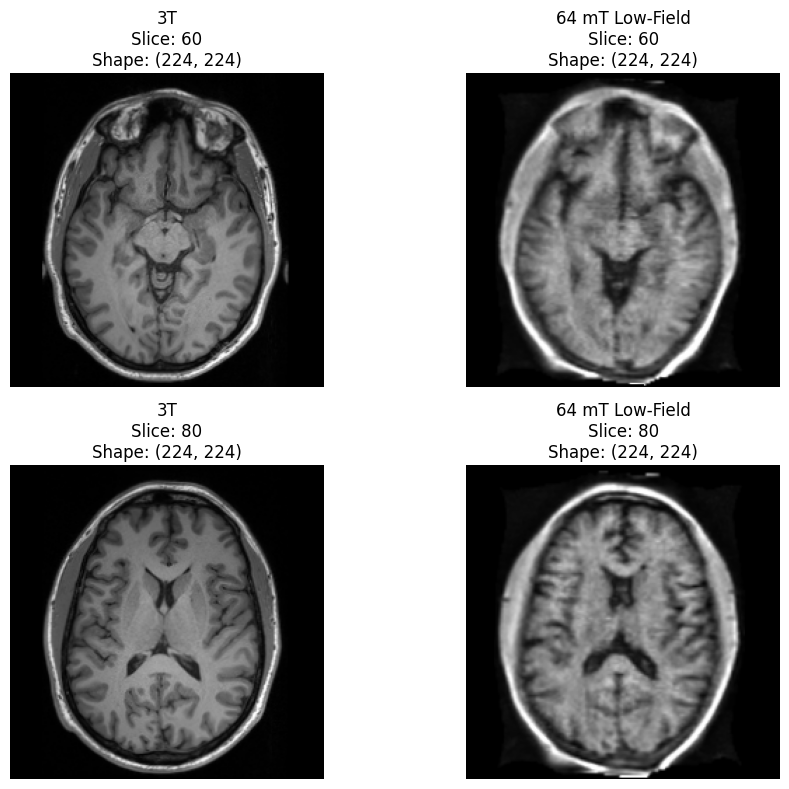

In [ ]:
# Choose several slice indices
slice_indices = [60, 80]

fig, ax = plt.subplots(
    len(slice_indices),
    2,
    figsize=(10, 4 * len(slice_indices))
)

for row, slice_idx in enumerate(slice_indices):

    # 3T
    ax[row, 0].imshow(
        mri_3T_norm[:, :, slice_idx].T,
        cmap="gray",
        origin="lower"
    )

    ax[row, 0].set_title(
        f"3T\nSlice: {slice_idx}\n"
        f"Shape: {mri_3T.shape[:2]}"
    )

    # 64 mT
    ax[row, 1].imshow(
        mri_64mT_norm[:, :, slice_idx].T,
        cmap="gray",
        origin="lower"
    )

    ax[row, 1].set_title(
        f"64 mT Low-Field\nSlice: {slice_idx}\n"
        f"Shape: {mri_64mT.shape[:2]}"
    )

    ax[row, 0].axis("off")
    ax[row, 1].axis("off")

plt.tight_layout()
plt.show()

<!-- Summary -->

<!-- Summary: Challenges and Possible Approaches -->

#⚠️ Challenges for Super-Resolution of Low-Field MRI

      The supervised CNN worked because we had:

      **LR image + corresponding HR reference**

  But for real low-field MRI, this assumption can be difficult.

    ### Major challenges

    - **No corresponding HR image**
      - A low-field scan may not have a matched high-resolution reference.

    - **HR image is available but not perfectly registered**
      - The LR and HR images may have differences in position,
      orientation, anatomy, or acquisition geometry.

    - **Different scanners / field strengths**
      - Low-field and high-field MRI can have different contrast,
       noise characteristics, and intensity distributions.

    - **Limited paired training data**
      - It can be difficult to obtain enough well-matched LR–HR
       pairs for supervised learning.

    - **Risk of hallucination**
      - A neural network may generate plausible-looking structures that
      are not supported by the acquired data.






# Explore for 5 Minutes the approaches that can be useful for this problem.

# Module 11 — What If HR Does Not Exist?

Everything we did depended on:

    LR + HR

The training process was:

                HR target
                    ↑
                    │
    LR → CNN → SR → Loss
                    │
                    ↓
                Optimizer

But suppose we have only:

                ONE LR MRI

and no corresponding clean HR MRI.

Then:

                LR → CNN → SR
                              ↑
                              ?
                         No HR target



## 🔬 What Other Approaches Can We Used ?

**If paired HR references are difficult to obtain, several approaches are possible:**



  ### 1. Synthetic Training Data

    Start with available HR images and simulate realistic low-field degradation:

    **HR → degradation model → simulated LR**

    Then train:

    **Simulated LR → CNN → HR**

    The challenge is making the simulated degradation representative of **real low-field MRI**.

    ---

  ### 2. Zero-Shot Super-Resolution (ZSSR)

    Train a model specifically for the **single input image**.

    **One LR image**
    ↓
    **Generate internal LR examples**
    ↓
    **Train CNN**
    ↓
    **Reconstruct higher-resolution image**

    No external HR reference is required during inference.

    ---

  ### 3. Unpaired / Domain Adaptation

    Use:

    **Low-field MRI dataset + separate HR MRI dataset**

    without requiring every LR image to have an HR counterpart.

    The model learns to reduce the difference between the two domains.

    ---


  ### 4. Physics / Acquisition-Informed Reconstruction

    Use knowledge of the MRI acquisition process:

    **k-space + MRI physics + neural network**


# Module 12 — Preview of Zero-Shot SR


> Can the image itself provide the training information?

The basic idea behind ZSSR is to generate
**internal training examples from the image itself**.

Conceptually:

                Image
                  │
             degradation
                  ↓
            smaller image
                  │
                  ↓
          internal training


---

# Module 13 — Final checkpoint


```markdown
# Final Checkpoint

Before moving to Next Notebook, make sure you can answer:

### Conceptual

1. What is the difference between HR and LR?
2. What is image degradation?
3. Why is interpolation not the same as SR?
4. What does a CNN learn in supervised SR?
5. Why are LR-HR patches required to be aligned?

### CNN

6. What does a convolution layer do?
7. Why do we use nonlinear activation functions?
8. What does the loss function measure?
9. What does backpropagation do?
10. What does the optimizer update?

### SR

11. What is the difference between upsampling and super-resolution?
12. Why can patch extraction be useful?
13. Why is hallucination a concern in medical imaging?


14. What happens if we have an LR image but no HR target?
15. What measures used to measure improvements in case of no HR target ?